<!--- ![tudd-neu.png](attachment:tudd-neu.png) --->
<img src="tudd-neu.png" alt="drawing" width="200"/>

Professur für Angewandte Umweltsystemanalyse an der TU Dresden <br/>
Prof. Dr.-Ing. habil. Olaf Kolditz <br/>
***Hydroinformatik (UW-BHW-414)*** <br/>
*[Lehre-Webseite](https://www.ufz.de/index.php?de=52702)*

**Übung: EX20 Jupyter Notebook Mechanik**

Dieses Notebook entwickeln wir für die kontinuumsmechanischen Aufgaben:

Inhalt:
- EX21: Skalarprodukt, Divergenz
- EX22: Divergenzfreie Strömung

***EX21: Skalarprodukt, Divergenz***

$\nabla \cdot \mathbf{v} = 0$

$\frac{\partial v_x}{\partial x} + \frac{\partial v_y}{\partial y} + \frac{\partial v_z}{\partial z} = 0$

% Define the 2D velocity field
Let $\mathbf{u} = (u, v)$ be a velocity field in $\mathbb{R}^2$, where $u = u(x,y)$ and $v = v(x,y)$.

% The divergence-free condition
The flow is divergence-free (incompressible) if it satisfies:
$
\nabla \cdot \mathbf{u} = \frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} = 0.
$

% Introduction of the stream function
Because the flow is divergence-free in 2D, there exists a stream function $\psi(x,y)$ such that:
$$
u = \frac{\partial \psi}{\partial y}, \qquad v = -\frac{\partial \psi}{\partial x}.
$$

% Proof of the condition via the stream function
Substituting these into the divergence equation verifies the condition automatically:
\begin{equation}
\nabla \cdot \mathbf{u} = \frac{\partial}{\partial x}\left(\frac{\partial \psi}{\partial y}\right)
 + \frac{\partial}{\partial y}\left(-\frac{\partial \psi}{\partial x}\right)
 = \frac{\partial^2 \psi}{\partial x \partial y}
 - \frac{\partial^2 \psi}{\partial y \partial x} = 0.
\end{equation}

% Vorticity transport formulation
The scalar vorticity $\omega$ in 2D is defined as:
\begin{equation}
\omega = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}.
\end{equation}
Substituting the stream function yields the Poisson equation:
\begin{equation}
\omega = -\nabla^2 \psi = -\left( \frac{\partial^2 \psi}{\partial x^2}
 + \frac{\partial^2 \psi}{\partial y^2} \right).
\end{equation}

\begin{align}
u(x,y) &= \frac{x-L}{(x-L)^2 + y^2} - \frac{x+L}{(x+L)^2 + y^2}, \\
v(x,y) &= \frac{y}{(x-L)^2 + y^2} - \frac{y}{(x+L)^2 + y^2}.
\end{align}

C:\Users\okolditz\AppData\Local\Temp\ipykernel_4252\3121954958.py:12: RuntimeWarning: invalid value encountered in divide
  vx = (x-L)/((x-L)**2+y**2) - (x+L)/((x+L)**2 +y**2)
C:\Users\okolditz\AppData\Local\Temp\ipykernel_4252\3121954958.py:13: RuntimeWarning: invalid value encountered in divide
  vy = y/((x-L)**2+y**2) - y/((x+L)**2 +y**2)


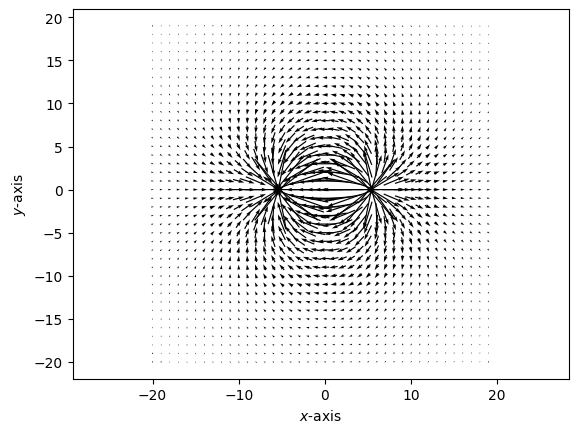

In [1]:
import numpy as np
import matplotlib.pyplot as plt
#matplotlib notebook
# set up a normalized grid:
dim= 20
xarray= np.arange(-dim,dim)
yarray= np.arange(-dim,dim)

# (fluid) flow from a source at L to a sink at -L:
L = dim/4
x,y = np.meshgrid(xarray,yarray)
vx = (x-L)/((x-L)**2+y**2) - (x+L)/((x+L)**2 +y**2)
vy = y/((x-L)**2+y**2) - y/((x+L)**2 +y**2)

# Masking the singularities at the poles:
threshold = 0.8
Mx = np.abs(vx) > threshold
My = np.abs(vy) > threshold
vx = np.ma.masked_array(vx, mask=Mx)
vy = np.ma.masked_array(vy, mask=My)

# plot the flow lines:
plt.figure()
plt.quiver(x,y, vx, vy, pivot='mid')
plt.xlabel("$x$-axis")
plt.ylabel("$y$-axis")
plt.axis('equal')
plt.show()

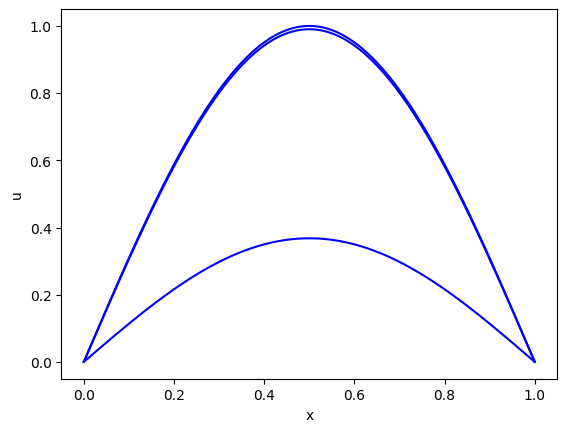

In [3]:
import math
import matplotlib.pylab as plt
PI = 3.14159265358979323846
numPoints = 100
alpha = 1.0
t = [0.01,0.1,1.0]
x = []
y = []
for n in t:
    for i in range(0,numPoints+1):
        x.append(float(i)/float(numPoints))
        #y.append(math.sin(PI*x[i]) * math.exp(-alpha*n*n))
        y.append(math.sin(math.pi*x[i]) * math.exp(-alpha*n*n))
    plt.plot(x,y,color='blue')
    x = []
    y = []
plt.xlabel('x')
plt.ylabel('u')
plt.axis('tight')
plt.savefig("diffusion-equation.png")
plt.show()

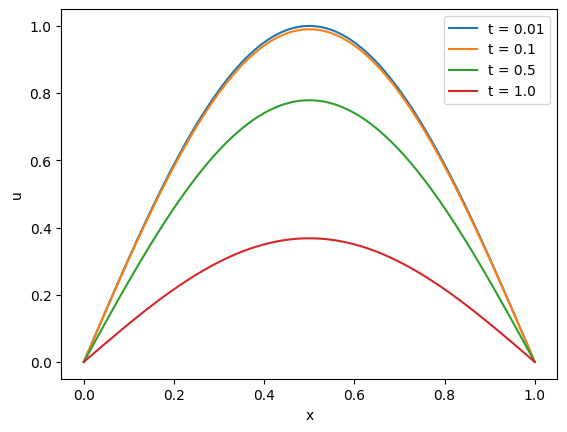

In [5]:
import math
import matplotlib.pylab as plt

PI = 3.14159265358979323846
numPoints = 100
alpha = 1.0
t = [0.01, 0.1,0.5,1.0]

for n in t:
    x = []
    y = []
    for i in range(0, numPoints + 1):
        xi = float(i) / float(numPoints)
        x.append(xi)
        y.append(math.sin(math.pi * xi) * math.exp(-alpha * n * n))
    
    # Added the 'label' parameter to distinguish each curve
    plt.plot(x, y, label=f't = {n}')

plt.xlabel('x')
plt.ylabel('u')

# Added legend to display the labels
plt.legend()

plt.axis('tight')
plt.savefig("diffusion-equation.png")
plt.show()